In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score, confusion_matrix, classification_report


data = pd.read_csv(r"C:\Users\User\Downloads\Mashroom\7.4.3.1_mushroom_competition_train_data.csv")

X = data.drop(columns=["Id"]).copy()
y = X.pop("poisonous")

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

cat_cols = ["cap.shape", "cap.color", "stalk.color.above.ring", "stalk.color.below.ring", "population"]

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="infrequent_if_exist"), cat_cols),
    remainder="passthrough"
)

pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=123)
)

param_grid = {
    "randomforestclassifier__n_estimators": [200, 300, 500],
    "randomforestclassifier__max_depth": [10, 20, 30, None],
    "randomforestclassifier__min_samples_split": [2, 5, 10],
    "randomforestclassifier__min_samples_leaf": [1, 2, 4],
    "randomforestclassifier__class_weight": [{0:1, 1:2}, {0:1, 1:3}, {0:1, 1:5}]
}

RFC_pipe = RandomizedSearchCV(
    pipe,
    param_grid,
    n_iter=50,
    cv=5,
    scoring=make_scorer(recall_score, pos_label=1),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

RFC_pipe.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestclassifier__class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3}, ...], 'randomforestclassifier__max_depth': [10, 20, ...], 'randomforestclassifier__min_samples_leaf': [1, 2, ...], 'randomforestclassifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(r..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=Fa

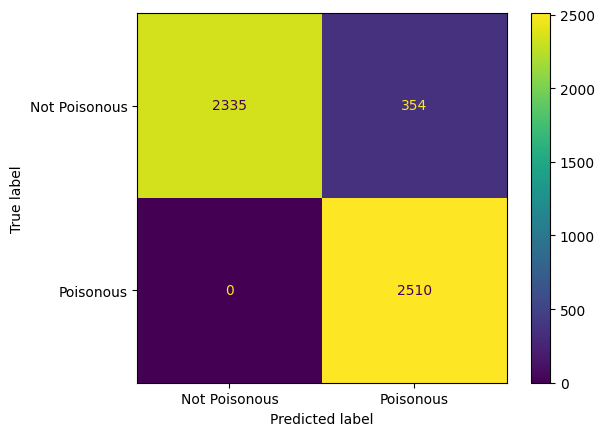

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(RFC_pipe, X_train, y_train, display_labels=['Not Poisonous', 'Poisonous'])

In [4]:
from sklearn.metrics import recall_score

recall_score(y_true=y_test, y_pred=RFC_pipe.predict(X_test))

1.0

In [11]:
url = "https://drive.google.com/file/d/1eWxV9FGj6D-YnMsv4mHMWRcGIKbjrXYL/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
new_data = pd.read_csv(path)

In [12]:
id_col = new_data.pop("Id")

In [13]:
order_of_columns = X.columns.to_list()
new_data = new_data[order_of_columns]

In [14]:
poisonous_pred = RFC_pipe.predict(new_data)

In [15]:
submission_file = pd.DataFrame({
    'Id':id_col,
    'poisonous':poisonous_pred
})

In [16]:
submission_file.head()

,Id,poisonous
0,5165,1
1,4281,1
2,231,0
3,3890,0
4,1521,1


In [17]:
submission_file.to_csv(r"C:\Users\User\Downloads\Mashroom\submission_3.csv",index=False)